# xQAOA on hardware — lean run

A stripped-down version of `demo.ipynb`. It does only what is needed to take one
knapsack instance from `knapsacks.h5` all the way to a hardware result:

1. **Setup** — load the instance and solve it with Gurobi for reference.
2. **Circuits** — warm-start state preparation, the ring copula mixer, and the cost layer.
3. **Training** — optimise $(\beta_p, \gamma_p)$ layer by layer on an MPS simulator, up to 5 layers.
4. **Hardware** — transpile, submit as a batch, retrieve the counts.
5. **Analysis** — approximation ratios and value distributions, compared against Gurobi.

The explanatory material (plots of the instance, greedy/lazy-greedy comparisons, copula
unit tests, simulator-vs-hardware cross checks, random baseline) lives in `demo.ipynb`.

## 1. Setup

In [1]:
import ast
import json
from collections import defaultdict
from itertools import islice

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from tqdm.auto import tqdm

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as RuntimeSamplerV2

from ADMM.scripts.solvers.classical_solver_UC import gurobi_knapsack_solver
from scripts.utils.kp_utils import (
    compute_approximate_ratio,
    get_value,
    get_weight,
    probabilty_success,
)

Load the knapsack instances and pick the one we want to run.

In [2]:
def load_knapsacks(file):
    instances = []
    with h5py.File(file, "r") as f:
        for key in sorted(f.keys(), key=lambda x: int(x)):
            grp = f[key]
            instance = {}
            for k, v in grp.items():
                data = v[()]
                if isinstance(data, bytes):
                    data = data.decode("utf-8")
                if isinstance(data, str) and data.startswith("[") and data.endswith("]"):
                    try:
                        data = np.array(ast.literal_eval(data), dtype=float)
                    except Exception:
                        pass
                if isinstance(data, np.generic):
                    data = data.item()
                instance[k] = data
            instances.append(instance)
    return instances


instance_index = 0
instances = load_knapsacks("knapsacks.h5")
instance = instances[instance_index]

weights = np.array(instance["weights"])
values = np.array(instance["values"])
capacity = instance["capacity"]
type_ = instance["type"]
k = instance["k"]
n = instance["n"]
ratios = values / weights

# The `from_hard_paper` instances are the ones we cannot drive to optimality quickly, so
# we loosen the Gurobi gap and override the stored inverse temperature.
if type_ == "from_hard_paper":
    OG = 0.1
    k = 8
else:
    OG = 1e-9

print(f"Instance {instance_index} is of type {type_}")
print(f"Number of qubits (items): {n}")
print(f"Inverse temperature k used for the warm start: {k}")
print(f"Capacity: {capacity:.4e}")

Instance 0 is of type from_hard_paper
Number of qubits (items): 100
Inverse temperature k used for the warm start: 8
Capacity: 1.0000e+10


## 2. Circuits

### Warm-start distribution

The warm start is the "smoothed lazy greedy" distribution: take the lazy greedy solution
(stop at the first item that does not fit), find its cutoff value/weight ratio, and smooth
the 0/1 inclusion indicator into a logistic curve of inverse temperature $k$.

In [3]:
def construct_lazy_greedy_solution(weights, ratios, capacity):
    lazy_greedy_weight = 0
    lazy_greedy_solution = np.zeros(len(weights), dtype=bool)
    greedy_order = np.lexsort((-weights, -ratios))
    for i in greedy_order:
        if lazy_greedy_weight + weights[i] <= capacity:
            lazy_greedy_solution[i] = True
            lazy_greedy_weight += weights[i]
        else:
            break
    return lazy_greedy_solution


def construct_smoothed_lazy_greedy_distribution(weights, values, capacity, inv_temp):
    ratios = values / weights
    lazy_greedy_solution = construct_lazy_greedy_solution(weights, ratios, capacity)
    cutoff_ratio = np.min(ratios[lazy_greedy_solution])
    uniform_probability = np.sum(weights) / capacity
    return 1 / (1 + (uniform_probability - 1) * np.exp(-inv_temp * (ratios - cutoff_ratio)))


warm_start_distribution = construct_smoothed_lazy_greedy_distribution(
    weights, values, capacity, k
)

### Qubit layout and state preparation

One qubit per item. Qubits are ordered by decreasing value/weight ratio (weight as
tiebreaker) so that neighbouring qubits carry items of similar ratio — this is what makes
the ring mixer swap items of comparable ratio, and hence approximately preserve weight.
Each qubit is rotated into $\sqrt{1-p_i}\,|0\rangle + \sqrt{p_i}\,|1\rangle$.

In [4]:
qubit_order = np.lexsort((-weights, -ratios))

qubit_ordered_distribution = warm_start_distribution[qubit_order]
ordered_weights = weights[qubit_order]
ordered_values = values[qubit_order]
ordered_ratios = ratios[qubit_order]


def initialize_warm_start_distribution(quantum_circuit, distribution):
    """Rotate every qubit so that its measurement statistics match `distribution`."""
    for i in range(len(distribution)):
        angle = 2 * np.arcsin(np.sqrt(distribution[i]))
        quantum_circuit.ry(angle, i)
    quantum_circuit.barrier()
    return quantum_circuit

### Gurobi reference solution

We solve in the ratio-ordered basis so that the returned bitstring lines up with the qubit
layout above. The optimal *value* is of course independent of the ordering.

In [5]:
result_gurobi = gurobi_knapsack_solver(
    ordered_values,
    ordered_weights,
    capacity,
    verbose=False,
    time_limit=60,
    optimality_gap=OG,
    feasibility_tolerance=1e-9,
)

optimal_value = result_gurobi["total_value"]
optimal_weight = result_gurobi["total_weight"]
gurobi_mask = np.array([c == "1" for c in result_gurobi["bitstring"]], dtype=bool)

print(f"Gurobi value:  {optimal_value:.4e}")
print(f"Gurobi weight: {optimal_weight:.4e}  (capacity respected: {capacity >= optimal_weight})")
print(f"Runtime: {result_gurobi['runtime']:.6f} s")

Restricted license - for non-production use only - expires 2026-11-23
Gurobi value:  9.6889e+09
Gurobi weight: 9.6889e+09  (capacity respected: True)
Runtime: 0.003044 s


### The copula mixer

The two-qubit copula mixer of [arXiv:2108.08805](https://arxiv.org/abs/2108.08805). We
build the rotation that maps $|00\rangle$ to the copula state $|p_{\rm cop}\rangle$, apply
the mixer diagonally in that rotated basis, then rotate back. `theta = -1` gives maximal
anticorrelation between the pair.

In [6]:
def construct_cop(p_1, p_2, beta, theta=-1):
    """
    Constructs a two qubit copula mixer with the given parameters.

    Args:
        p_1 (float): Probability p_1 in the definition of the copula mixer.
        p_2 (float): Probability p_2 in the definition of the copula mixer.
        beta (float): The strength of the copula mixer.
        theta (float): Controls whether qubits are correlated or anti-correlated. Takes
            values in [-1, 1] and defaults to -1, i.e. maximum anticorrelation.

    Returns:
        QuantumCircuit: The two-qubit copula mixer.
    """
    # We first construct a rotation operator designed to rotate |00> to the |p_cop> state.
    rotation_circuit = QuantumCircuit(2)
    phi_1 = 2 * np.arcsin(np.sqrt(p_1))
    p_2_given_1 = (p_1 * p_2 + theta * p_1 * p_2 * (1 - p_1) * (1 - p_2)) / p_1
    phi_2_given_1 = 2 * np.arcsin(np.sqrt(p_2_given_1))
    p_2_given_not1 = ((1 - p_1) * p_2 - theta * p_1 * p_2 * (1 - p_1) * (1 - p_2)) / (1 - p_1)
    phi_2_given_not1 = 2 * np.arcsin(np.sqrt(p_2_given_not1))

    rotation_circuit.ry(phi_1, 0)  # Rotate first qubit to the correct marginal distribution
    rotation_circuit.cry(phi_2_given_1, control_qubit=0, target_qubit=1)  # Joint dist. if qubit 0 is |1>
    rotation_circuit.x(0)  # Flip qubit 0
    rotation_circuit.cry(phi_2_given_not1, control_qubit=0, target_qubit=1)  # Joint dist. if qubit 0 is |0>
    rotation_circuit.x(0)  # Undo flip

    copula_mixer = QuantumCircuit(2)
    copula_mixer.compose(rotation_circuit.inverse(), inplace=True)  # rotate |p_cop> to |00>
    copula_mixer.barrier()
    # In this rotated basis the copula mixer is diagonal, so we implement it with RZ gates.
    copula_mixer.rz(-2 * beta, 0)
    copula_mixer.rz(-2 * beta, 1)
    copula_mixer.barrier()
    copula_mixer.compose(rotation_circuit, inplace=True)  # rotate |00> back to |p_cop>

    return copula_mixer


def add_ring_copula(quantum_circuit, probability_dist, beta):
    """Applies the two-qubit copula mixer to nearest neighbours on a ring of qubits."""
    n = len(probability_dist)
    for i in range(1, n, 2):
        p_1 = probability_dist[i]
        p_2 = probability_dist[(i + 1) % n]
        copula_mixer = construct_cop(p_1, p_2, beta)
        quantum_circuit.compose(copula_mixer, qubits=[i, (i + 1) % n], inplace=True)

    for i in range(2, n, 2):
        p_1 = probability_dist[i]
        p_2 = probability_dist[(i + 1) % n]
        copula_mixer = construct_cop(p_1, p_2, beta)
        quantum_circuit.compose(copula_mixer, qubits=[i, (i + 1) % n], inplace=True)

    quantum_circuit.barrier()
    return quantum_circuit

### Cost layer

The constraint is carried (softly) by the mixer, so the cost function is just the total
value of the selected items. Values are normalised by the largest value so that $\gamma$
lives in $[0, 2\pi]$.

In [7]:
def add_knapsack_cost_function(quantum_circuit, values, gamma):
    """Phase-separation layer: a phase proportional to each item's value."""
    max_value = np.max(values)
    n = len(values)
    for i in range(n):
        quantum_circuit.p(gamma * values[i] / max_value, i)
    quantum_circuit.barrier()
    return quantum_circuit

## 3. Training

### Simulator and backend

The backend is only used for its coupling map / basis gates during training; the actual
circuit execution is on the Aer matrix-product-state simulator. The same backend is the
target of the hardware run further down.

In [ ]:
# service = QiskitRuntimeService()
backend=service.least_busy(min_num_qubits=100)

optimization_level = 3
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=optimization_level, seed_transpiler=111
)

nm = None  # noise model: None -> noiseless MPS simulation during training
coupling_map = backend.configuration().coupling_map
basis_gates = backend.basis_gates

sampler_mps = AerSamplerV2(
    options={
        "backend_options": {
            "method": "matrix_product_state",
            "noise_model": nm,
            "coupling_map": coupling_map,
        },
    },
)

In [9]:
print(backend)

<IBMBackend('ibm_marrakesh')>


The training objective. We sample the circuit, throw away every bitstring that violates
the capacity constraint, and return the value expectation over the surviving shots. This is
noticeably quicker than an estimator-based objective.

In [11]:
def sampler_based_optimizer(qc, capacity, shots=10_000):
    qc = transpile(qc, basis_gates=backend.basis_gates)
    qc.measure_active()
    job = sampler_mps.run([(qc,)], shots=shots)
    sampler_result = job.result()
    sampled_counts = sampler_result[0].data.meas.get_counts()
    shots = sum(sampled_counts.values())
    filtered_bitstrings = []
    filtered_cost_values = []
    for key in sampled_counts.keys():
        if get_weight(key[::-1], ordered_weights) <= capacity:
            filtered_bitstrings.append(key)
            filtered_cost_values.append(
                get_value(key[::-1], ordered_values) * sampled_counts[key] / shots
            )
        else:
            continue
    filtered_distribution = {
        key: val / shots for key, val in sampled_counts.items() if key in filtered_bitstrings
    }
    filtered_exp_val = sum(filtered_cost_values)

    return filtered_distribution, filtered_exp_val


* I start with a p=1 QAOA circuit with unassigned, $\beta$ and $\gamma$ parameters.  I do `max_iter**2` number of optimization loops, each starting at a different initial value. At the end, I take the parameters that lead to the largest value of the cost function, out of all the `max_iter**2` optimization loop and take those to be the optimal parameters.
* Once the optimal parameters for the first layer have been calculated, I then assign those parameters to $\beta$ and $\gamma$, add another qaoa layer with unassigned $\beta$ and $\gamma$, and repeat the first step, all the way up to 5 QAOA layers.

In [ ]:
layers = 5
max_iter = 4
params = []
results = {}
shots = 10_000
p_values = [1, 2, 3, 4, 5]

gammas = [Parameter(f"gamma_{i}") for i in p_values]
betas = [Parameter(f"beta_{i}") for i in p_values]


def cost_to_minimize(params: list, qc: QuantumCircuit):
    circ = qc.copy()
    # Qiskit orders free parameters by name, so at layer p the vector is (beta_p, gamma_p).
    circ.assign_parameters(params, inplace=True)
    _, cost = sampler_based_optimizer(circ, capacity=capacity, shots=shots)
    return -cost


# def __optimization_loop__(qc, max_iter=max_iter):
#     x_vals = []
#     y_vals = []
#     for i in range(max_iter):
#         for k in range(max_iter):
#             init_params = [i * np.pi / (max_iter - 1), 2 * k * np.pi / (max_iter)]
#             result_lc = minimize(
#                 cost_to_minimize,
#                 init_params,
#                 args=qc,
#                 method="COBYLA",
#                 bounds=[(0, np.pi), (0, 2 * np.pi)],
#                 tol=1e-2,
#             )
#             print(result_lc)
#             y_vals.append(cost_to_minimize(list(result_lc.x), qc))
#             x_vals.append((result_lc.x))

#     min_params = x_vals[np.argmin(y_vals)]
#     return min_params

# from concurrent.futures import ProcessPoolExecutor
# import os


# def run_cobyla_start(args):
#     start, qc = args
#     result = minimize(
#         cost_to_minimize,
#         start,
#         args=(qc,),
#         method="COBYLA",
#         bounds=[(0, np.pi), (0, 2 * np.pi)],
#         tol=1e-2,
#     )
#     return result.x, result.fun


# starts = [
#     [i * np.pi / (max_iter - 1), 2 * k * np.pi / max_iter]
#     for i in range(max_iter)
#     for k in range(max_iter)
# ]

# def _optimization_loop_(qc):
#     with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
#         results = list(
#             executor.map(
#                 run_cobyla_start,
#                 [(start, qc) for start in starts],
#             )
#         )
#     best_params = min(results, key=lambda result: result[1])[0]
#     return best_params


# qc = QuantumCircuit(n)
# qc = initialize_warm_start_distribution(qc, qubit_ordered_distribution)
# circuits_at_different_p = []
# with tqdm(total=layers) as pbar:
#     for p in range(layers):
#         qc = add_knapsack_cost_function(qc, ordered_values, gamma=gammas[p])
#         qc = add_ring_copula(qc, qubit_ordered_distribution, beta=betas[p])
#         #min_params = __optimization_loop__(qc)
#         min_params = _optimization_loop_(qc)
#         #params.append((min_params))
#         qc.assign_parameters(min_params, inplace=True)
#         circuits_at_different_p.append(qc.copy())
#         pbar.update(1)

In [ ]:
# Learned parameters from the training above

from numpy import array
params = [array([2.83787991, 0.41617059]),array([0.10239941, 5.69886667]),array([0.16056469, 5.23078654]),array([0.00990624, 4.1402265]),array([3.09954674, 3.13302174]),
]

In [16]:
for i in range(len(params)):
    print(f"Optimized parameters (beta, gamma) for p={i + 1}: {params[i]}")

Optimized parameters (beta, gamma) for p=1: [2.83787991 0.41617059]
Optimized parameters (beta, gamma) for p=2: [0.10239941 5.69886667]
Optimized parameters (beta, gamma) for p=3: [0.16056469 5.23078654]
Optimized parameters (beta, gamma) for p=4: [0.00990624 4.1402265 ]
Optimized parameters (beta, gamma) for p=5: [3.09954674 3.13302174]


In [20]:
qc = QuantumCircuit(n)
qc = initialize_warm_start_distribution(qc, qubit_ordered_distribution)
circuits_at_different_p = []
with tqdm(total=layers) as pbar:
    for p in range(layers):
        qc = add_knapsack_cost_function(qc, ordered_values, gamma=gammas[p])
        qc = add_ring_copula(qc, qubit_ordered_distribution, beta=betas[p])
        qc.assign_parameters(params[p], inplace=True)
        circuits_at_different_p.append(qc.copy())

  0%|          | 0/5 [00:00<?, ?it/s]

Training is the expensive part of this notebook, so persist the parameters. Re-running the
cell below after a fresh kernel start (with training skipped) rebuilds
`circuits_at_different_p` from disk.

In [ ]:
params_file = f"./Counts/Simulations/Instance:{instance_index},trained_params.json"

# Save
with open(params_file, "w") as f:
    json.dump([list(map(float, p)) for p in params], f, indent=4)

# --- Reload path: uncomment to rebuild the circuits without retraining ---------------
# with open(params_file) as f:
#     params = [np.array(p) for p in json.load(f)]
#
# qc = QuantumCircuit(n)
# qc = initialize_warm_start_distribution(qc, qubit_ordered_distribution)
# circuits_at_different_p = []
# for p in range(layers):
#     qc = add_knapsack_cost_function(qc, ordered_values, gamma=gammas[p])
#     qc = add_ring_copula(qc, qubit_ordered_distribution, beta=betas[p])
#     qc.assign_parameters(params[p], inplace=True)
#     circuits_at_different_p.append(qc.copy())

## 4. Hardware run

Add measurements and transpile each trained circuit for the backend. One PUB per QAOA
depth, so a single batch returns all five depths.

In [31]:
pubs = []
for circ in circuits_at_different_p:
    circ = circ.copy()  # copy so this cell stays safe to re-run
    circ.measure_active()
    pubs.append(pm.run(circ))

for p, pub in zip(p_values, pubs):
    print(f"p={p}: depth={pub.depth(lambda x:len(x.qubits)==2)}, two-qubit gates={pub.num_nonlocal_gates()}")

p=1: depth=12, two-qubit gates=380
p=2: depth=24, two-qubit gates=760
p=3: depth=36, two-qubit gates=1140
p=4: depth=48, two-qubit gates=1520
p=5: depth=60, two-qubit gates=1900


In [22]:
SHOTS = 100000

with Batch(backend=backend) as batch:
    sampler = RuntimeSamplerV2(mode=batch)
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XY4"
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.enable_measure = True
    sampler.options.default_shots = SHOTS
    sampler.options.twirling.strategy = "active-circuit"

    job = sampler.run(pubs=pubs)
    print(f"job_id:{job.job_id()}")

job_id:danj79g2fm4c73f49n50


## 5. Analysis

Bin the returned bitstrings by knapsack value, separating feasible from infeasible.

In [24]:
def convert_bitstring_to_values(counts, v, w, c):
    dict_bit_values_valid = {}
    dict_bit_values_invalid = {}

    for bitstring, count in tqdm(counts.items(), desc="Processing bitstrings", total=len(counts)):
        value = get_value(bitstring, v)
        if get_weight(bitstring, w) <= c:
            dict_bit_values_valid[value] = dict_bit_values_valid.get(value, 0) + count
        else:
            dict_bit_values_invalid[value] = dict_bit_values_invalid.get(value, 0) + count

    if not dict_bit_values_valid:
        print("No valid solutions found!")

    return dict_bit_values_valid, dict_bit_values_invalid

Retrieve the hardware counts. Set `JOB_ID` to reattach to a completed job in a later
session; leave it as `None` to use the job submitted above.

In [25]:
JOB_ID = None  # e.g. 'danj79g2fm4c73f49n50'

if JOB_ID is not None:
    job = service.job(JOB_ID)
print(f"Analyzing job {job.job_id()} (status: {job.status()})")

hardware_dict_bit_values_at_different_p = {}
hardware_summary = {}

for i in range(len(p_values)):
    counts_bin_qc = job.result()[i].data.meas.get_counts()

    counts_bin_qc_rev = {}  # reverse bitstrings to account for little endian notation
    for key in counts_bin_qc.keys():
        counts_bin_qc_rev[key[::-1]] = counts_bin_qc[key]

    valid_dict_bit_values_qaoa, invalid_dict_bit_values_qaoa = convert_bitstring_to_values(
        counts_bin_qc_rev, ordered_values, ordered_weights, capacity
    )

    # Sort the dictionary by value
    sorted_dict_valid_qaoa = dict(
        sorted(valid_dict_bit_values_qaoa.items(), key=lambda item: item[0], reverse=True)
    )
    hardware_dict_bit_values_at_different_p[f"p = {i}"] = sorted_dict_valid_qaoa

    best_value = max(sorted_dict_valid_qaoa.keys())
    valid_shots_qaoa = sum(sorted_dict_valid_qaoa.values())
    approx_ratio_qaoa, _ = compute_approximate_ratio(
        dict(islice(sorted_dict_valid_qaoa.items(), valid_shots_qaoa)), optimal_value
    )
    p_success_qaoa = probabilty_success(sorted_dict_valid_qaoa, optimal_value)
    hardware_summary[p_values[i]] = {
        "best_value": best_value,
        "approx_ratio": approx_ratio_qaoa,
        "valid_shots": valid_shots_qaoa,
        "p_success": p_success_qaoa,
    }

    # store counts dictionary
    counts_file = f"./Counts/Hardware/Instance:{instance_index}" + f"p:{p_values[i]}"
    with open(counts_file, "w") as f:
        json.dump(counts_bin_qc_rev, f, indent=4)

    print(f"p = {p_values[i]}: best value {best_value:.6e}, "
          f"approximate ratio {approx_ratio_qaoa}, valid shots {valid_shots_qaoa}")

Analyzing job danj79g2fm4c73f49n50 (status: DONE)


Processing bitstrings:   0%|          | 0/99999 [00:00<?, ?it/s]

p = 1: best value 9.689004e+09, approximate ratio 0.6843763450614881, valid shots 27489


Processing bitstrings:   0%|          | 0/100000 [00:00<?, ?it/s]

p = 2: best value 9.688904e+09, approximate ratio 0.7696229210887138, valid shots 9542


...

p = 3: best value 9.689005e+09, approximate ratio 0.8221560206267955, valid shots 3903


Processing bitstrings:   0%|          | 0/100000 [00:00<?, ?it/s]

p = 4: best value 9.689105e+09, approximate ratio 0.8346354833214263, valid shots 2054


Processing bitstrings:   0%|          | 0/100000 [00:00<?, ?it/s]

p = 5: best value 9.689105e+09, approximate ratio 0.841401075636032, valid shots 1010


The classical warm start, sampled the same number of times, is our point of comparison:
anything xQAOA buys us has to show up as an improvement over this.

In [26]:
warm_start_counts = defaultdict(int)
for _ in range(SHOTS):
    bitstring = "".join(str(int(np.random.random() < pi)) for pi in qubit_ordered_distribution)
    warm_start_counts[bitstring] += 1

valid_dict_bit_values_ws, _ = convert_bitstring_to_values(
    warm_start_counts, ordered_values, ordered_weights, capacity
)

sorted_dict_ws = dict(
    sorted(valid_dict_bit_values_ws.items(), key=lambda item: item[0], reverse=True)
)
valid_shots_ws = sum(sorted_dict_ws.values())
approx_ratio_ws, _ = compute_approximate_ratio(
    dict(islice(sorted_dict_ws.items(), valid_shots_ws)), optimal_value
)
p_success_ws = probabilty_success(valid_dict_bit_values_ws, optimal_value)
best_value_ws = max(valid_dict_bit_values_ws.keys())

print(f"Best warm-start value: {best_value_ws:.6e}")
print(f"Warm-start approximate ratio: {approx_ratio_ws}")
print(f"Number of valid warm-start shots: {valid_shots_ws}")

Processing bitstrings:   0%|          | 0/98518 [00:00<?, ?it/s]

Best warm-start value: 9.688604e+09
Warm-start approximate ratio: 0.5932502474618336
Number of valid warm-start shots: 52961


### Comparison with Gurobi

In [27]:
print(f"Gurobi value: {optimal_value:.6e}   (optimality gap requested: {OG})")
print()
header = f"{'method':>14} | {'best value':>13} | {'best/Gurobi':>11} | {'approx ratio':>12} | {'valid shots':>11}"
print(header)
print("-" * len(header))
print(f"{'warm start':>14} | {best_value_ws:13.6e} | {best_value_ws / optimal_value:11.7f} | "
      f"{approx_ratio_ws:12.5f} | {valid_shots_ws:11d}")
for p, row in hardware_summary.items():
    print(f"{f'xQAOA p={p}':>14} | {row['best_value']:13.6e} | "
          f"{row['best_value'] / optimal_value:11.7f} | {row['approx_ratio']:12.5f} | "
          f"{row['valid_shots']:11d}")

Gurobi value: 9.688907e+09   (optimality gap requested: 0.1)

        method |    best value | best/Gurobi | approx ratio | valid shots
-------------------------------------------------------------------------
    warm start |  9.688604e+09 |   0.9999688 |      0.59325 |       52961
     xQAOA p=1 |  9.689004e+09 |   1.0000100 |      0.68438 |       27489
     xQAOA p=2 |  9.688904e+09 |   0.9999997 |      0.76962 |        9542
     xQAOA p=3 |  9.689005e+09 |   1.0000101 |      0.82216 |        3903
     xQAOA p=4 |  9.689105e+09 |   1.0000204 |      0.83464 |        2054
     xQAOA p=5 |  9.689105e+09 |   1.0000204 |      0.84140 |        1010


### Value distributions

In [28]:
def plot_multiple_distributions(data_dict, min_cost=None,
                           bins_width=50, log=True, output_file=None,
                           colors=None, labels=None, title=None, nb_bins=200,
                           annotations=None, figsize=(10, 6), hist_type='step',
                           hardware=True, save_fig=True):
    """
    Plots histograms of multiple distributions on the same plot with optional vertical line.

    Parameters:
    data_dict (dict): Dictionary where keys are method names and values are dictionaries
                     with keys as data points and values as weights.
    min_cost (float, optional): The value at which to draw the vertical line.
    bins_width (int): Number of bins for the histograms.
    log (bool): Whether to use log scale for the axes.
    output_file (str, optional): File path to save the plot (e.g., "output.png").
    colors (dict, optional): Dictionary mapping method names to colors.
    labels (dict, optional): Dictionary mapping method names to display labels.
    title (str, optional): Title for the plot.
    annotations (dict, optional): Dictionary with annotation text and position.
    figsize (tuple): Figure size (width, height).
    hardware (bool): If the figure corresponds to hardware results or not.
    """
    default_colors = ['steelblue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive']

    if colors is None:
        colors = {method: default_colors[i % len(default_colors)]
                 for i, method in enumerate(data_dict.keys())}

    if labels is None:
        labels = {method: method for method in data_dict.keys()}

    fig, ax = plt.subplots(figsize=figsize)
    max_height = 0

    # Find the global range for consistent binning
    all_values = []
    for method, data in data_dict.items():
        if data:
            all_values.extend(list(data.keys()))

    if not all_values:
        print("No data to plot")
        return

    # Plot each distribution
    for i, (method, data) in enumerate(data_dict.items()):
        if not data:
            continue

        values = list(data.keys())
        weights = list(data.values())
        counts, bins, patches = ax.hist(
            values,
            weights=weights,
            bins=nb_bins,
            edgecolor=colors[method],
            alpha=0.6,
            stacked=True,
            color=colors[method],
            label=labels[method],
            histtype=hist_type,
            linewidth=1,
        )

        current_max = max(counts) if len(counts) > 0 else 0
        max_height = max(max_height, current_max)

    # Add vertical line for the optimal value if provided
    if min_cost is not None:
        ax.axvline(min_cost, linestyle="--", color="black", label="Gurobi", linewidth=1.5)

    if annotations:
        text = "\n".join([f"{k}: {v:}" for k, v in annotations.items()])
        fig.text(
            0, -0.1, text,
            transform=ax.transAxes,
            fontsize=10,
            ha="left",
            va="bottom",
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.4)
        )

    if log:
        ax.set_yscale("log")
        ax.set_xscale("log")

    ax.set_ylabel("Counts", fontsize=12)
    ax.set_xlabel("Values", fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10, loc='best');

    plt.tight_layout()

    if save_fig:
        plot_identifier = f'Instance:{instance_index}'
        if not hardware:
            output_file = './Plots/Simulations/' + plot_identifier
        else:
            output_file = './Plots/Hardware/' + plot_identifier
        plt.savefig(output_file, bbox_inches="tight", dpi=300);

    plt.show()

    return fig, ax

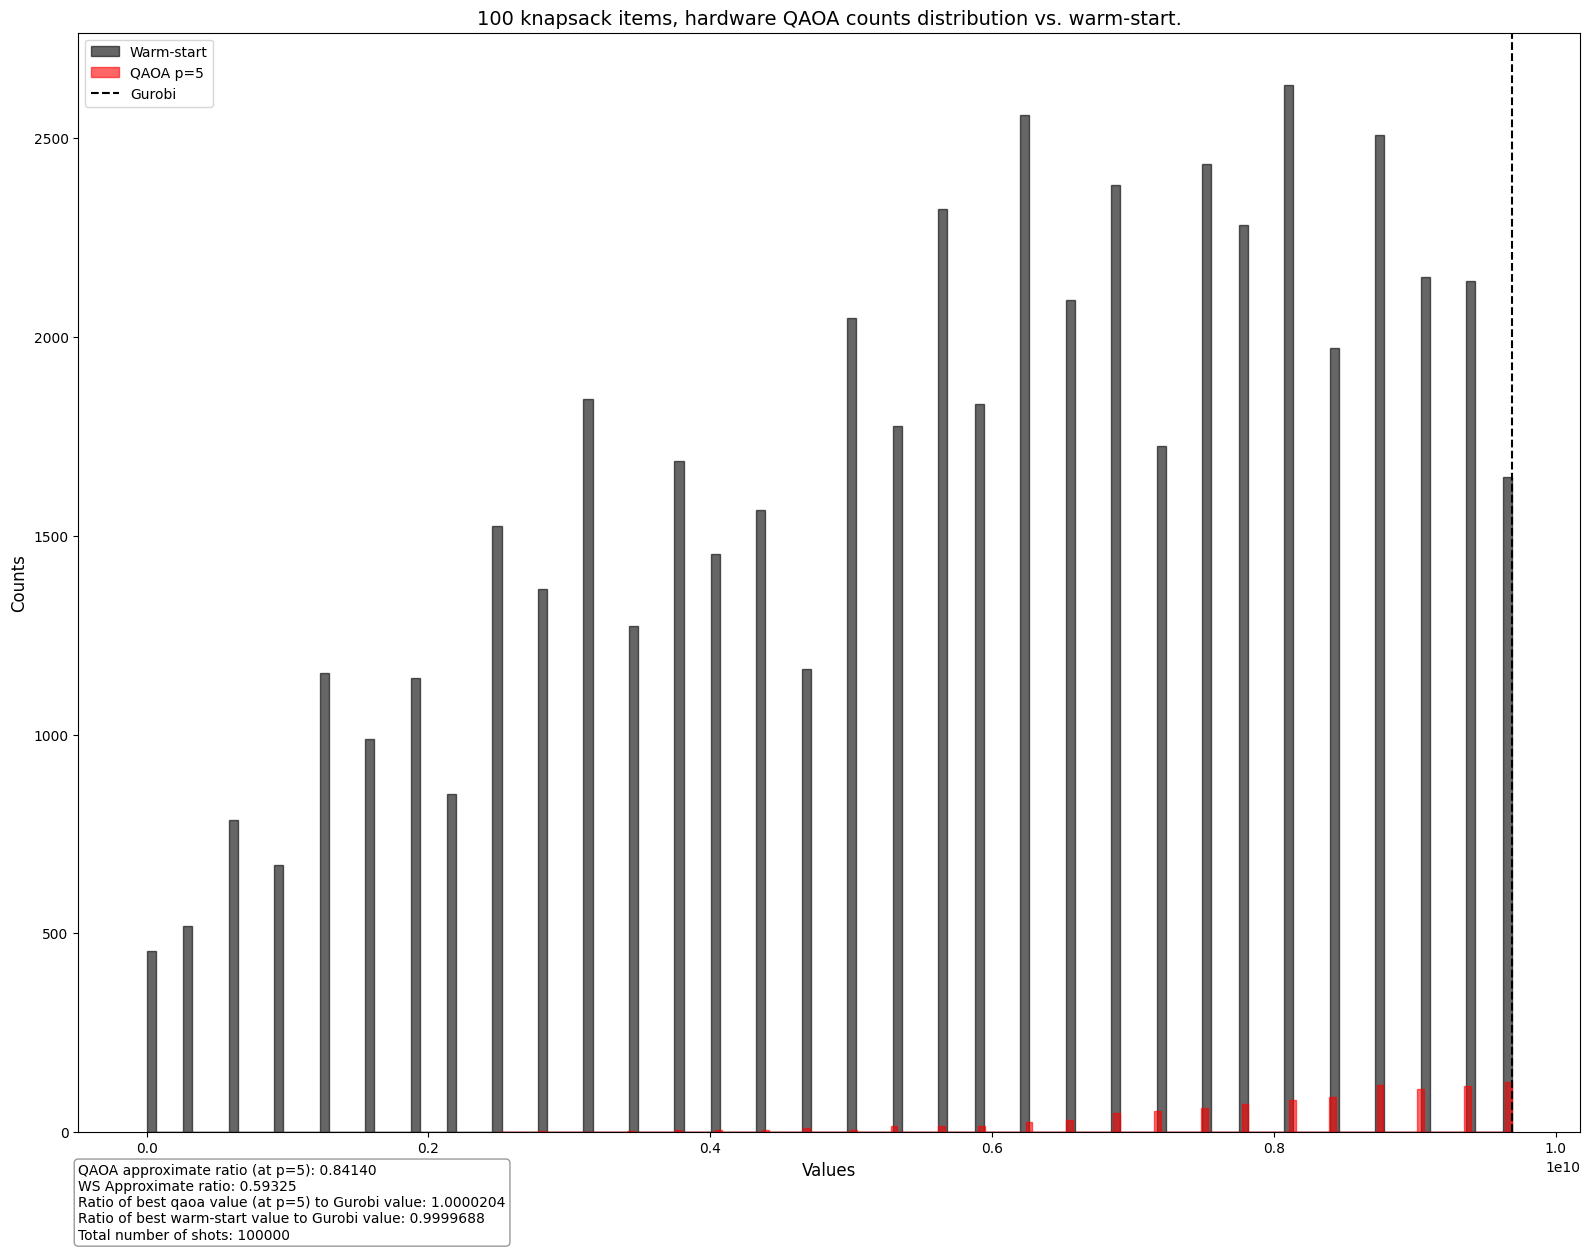

(<Figure size 1600x1200 with 1 Axes>,
 <Axes: title={'center': '100 knapsack items, hardware QAOA counts distribution vs. warm-start.'}, xlabel='Values', ylabel='Counts'>)

In [29]:
best_p = p_values[-1]

data_dict = {
    "Warm-start": valid_dict_bit_values_ws,
    f"QAOA p={best_p}": hardware_dict_bit_values_at_different_p[f"p = {best_p - 1}"],
}
colors = {
    "Warm-start": "black",
    f"QAOA p={best_p}": "red",
}
annotations = {
    f"QAOA approximate ratio (at p={best_p})": f"{hardware_summary[best_p]['approx_ratio']:.5f}",
    "WS Approximate ratio": f"{approx_ratio_ws:.5f}",
    f"Ratio of best qaoa value (at p={best_p}) to Gurobi value":
        f"{(hardware_summary[best_p]['best_value'] / optimal_value):.7f}",
    "Ratio of best warm-start value to Gurobi value": f"{(best_value_ws / optimal_value):.7f}",
    "Total number of shots": f"{SHOTS:.0f}",
}

plot_multiple_distributions(
    data_dict=data_dict,
    min_cost=optimal_value,
    colors=colors,
    nb_bins=150,
    log=False,
    annotations=annotations,
    figsize=(16, 12),
    hist_type="stepfilled",
    title=f"{n} knapsack items, hardware QAOA counts distribution vs. warm-start.",
    hardware=True,
)